<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cars = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2. Лінійна регресія/cars.csv")
cars.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [5]:
for col in cars.select_dtypes(int).columns:
    print(f'{col}:')
    value_count = cars[col].nunique()
    min = cars[col].min()
    max = cars[col].max()
    print(f'Кількість значень: {value_count}\nМінімальне значення: {min}\nМаксимальне значення: {max}')
    print()

Car_ID:
Кількість значень: 100
Мінімальне значення: 1
Максимальне значення: 100

Year:
Кількість значень: 6
Мінімальне значення: 2016
Максимальне значення: 2021

Kilometers_Driven:
Кількість значень: 18
Мінімальне значення: 10000
Максимальне значення: 60000

Mileage:
Кількість значень: 15
Мінімальне значення: 10
Максимальне значення: 25

Engine:
Кількість значень: 36
Мінімальне значення: 999
Максимальне значення: 4951

Power:
Кількість значень: 40
Мінімальне значення: 68
Максимальне значення: 396

Seats:
Кількість значень: 3
Мінімальне значення: 4
Максимальне значення: 7

Price:
Кількість значень: 31
Мінімальне значення: 450000
Максимальне значення: 4000000



In [6]:
cars['Seats'].unique()

array([5, 4, 7])

In [7]:
for col in cars.select_dtypes(object).columns:
    print(f"{col}:")
    print(sorted(cars[col].unique()))
    print()

Brand:
['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Toyota', 'Volkswagen']

Model:
['3 Series', '5 Series', '7 Series', 'A3', 'A4', 'A5', 'A6', 'Altroz', 'Ameo', 'Aspire', 'BR-V', 'C-Class', 'Camry', 'City', 'Civic', 'Corolla', 'Creta', 'E-Class', 'EcoSport', 'Elantra', 'Endeavour', 'Ertiga', 'Figo', 'Fortuner', 'GLA', 'GLC', 'GLE', 'Harrier', 'Innova', 'Innova Crysta', 'Mustang', 'Nexon', 'Passat', 'Polo', 'Q3', 'Q7', 'Ranger', 'S-Cross', 'Safari', 'Santro', 'Scorpio', 'Sonata', 'Swift', 'T-Roc', 'Thar', 'Tiago', 'Tigor', 'Tiguan', 'Vento', 'Venue', 'Verna', 'Vitara', 'WR-V', 'X1', 'X3', 'X5', 'XUV300', 'Yaris']

Fuel_Type:
['Diesel', 'Petrol']

Transmission:
['Automatic', 'Manual']

Owner_Type:
['First', 'Second', 'Third']



**Висновок**

В наборі даних 8 числових і 5 категоріальних колонок з них

Числові:
- Car_ID  - від 1 до 100
- Year - год выпуска с 2016 по 2021
- Kilometers_Driven - пробіг від 10 000 до 60 000
- Mileage - паливна ефективність від 10 до 25
- Engine - об'єм двигуна від 999 до 4951
- Power - потужність від 68 до 396
- Seats - кількість місць 4, 5 або 7
- Price від 450 000 до 4 000 000

Категоріальні:
- Brand - 11 брендів машин
- Model - 58 моделей
- Fuel_Type - насправді бінарний - Diesel або Petrol
- Transmission - також бінарний - Automatic або Manual
- Owner_Type - можна перевести в числовий, оскліьки це кількість попередніх власників


Результат:
- 2 бінарні - Fuel_Type і Transmission
- 2 мультикатегоріальних зі значеннями, для яких немає відношення порядку - Brand і Model
- 1 колонка, в яких можна встановити відношення порядку - Owner_Type

Дані не мають пропущених значень

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [8]:
cars.columns.drop(['Price'])

Index(['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats'],
      dtype='object')

In [9]:
input_cols = cars.columns.drop(['Price'])
inputs = cars[input_cols]
targets = cars['Price']
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

In [10]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 20 entries, 17 to 16
Series name: Price
Non-Null Count  Dtype
--------------  -----
20 non-null     int64
dtypes: int64(1)
memory usage: 320.0 bytes


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [11]:
cars['Fuel_Type'].value_counts()


,count
Fuel_Type,
Petrol,52
Diesel,48


In [12]:
Fuel_Type_codes = {'Diesel': 0, 'Petrol': 1}
X_train['Fuel_Type_codes'] = X_train['Fuel_Type'].map(Fuel_Type_codes)
X_test['Fuel_Type_codes'] = X_test['Fuel_Type'].map(Fuel_Type_codes)
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1


In [13]:
cars['Transmission'].value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [14]:
Transmission_codes = {'Manual': 0, 'Automatic': 1}
X_train['Transmission_codes'] = X_train['Transmission'].map(Transmission_codes)
X_test['Transmission_codes'] = X_test['Transmission'].map(Transmission_codes)
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1


In [15]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])

one_hot_train = enc.transform(X_train[['Brand']]).toarray()
X_train[enc.categories_[0]] = one_hot_train

one_hot_test = enc.transform(X_test[['Brand']]).toarray()
X_test[enc.categories_[0]] = one_hot_test

#X_train.head()
X_test.head()


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [16]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [17]:
X_train.head()
#X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00


In [18]:
X_train[['Brand','Model']].value_counts().sort_index()

Brand       Model        
Audi        A3               2
            A5               2
            A6               2
            Q7               2
BMW         3 Series         2
            5 Series         1
            7 Series         2
            X3               2
            X5               2
Ford        Aspire           1
            EcoSport         2
            Endeavour        1
            Mustang          3
            Ranger           2
Honda       BR-V             2
            Civic            1
            WR-V             2
Hyundai     Elantra          1
            Santro           1
            Sonata           1
            Venue            1
            Verna            2
Mahindra    Scorpio          1
            Thar             1
            XUV300           2
Maruti      S-Cross          2
            Swift            1
            Vitara           2
Mercedes    C-Class          3
            E-Class          2
            GLA              1
            GLC              1
            GLE              2
Tata        Altroz           3
            Harrier          1
            Nexon            1
            Safari           1
            Tiago            2
            Tigor            2
Toyota      Camry            2
            Corolla          1
            Fortuner         2
            Innova           1
            Innova Crysta    1
            Yaris            1
Volkswagen  Ameo             2
            Passat           2
            T-Roc            2
            Vento            1
Name: count, dtype: int64

Колонку Models можна привести до класу машини (Budget, Mid, Premium)c. Сам розподіл наявних моделей машин в X_train по класам проводив чат GPT

In [19]:
model_to_class = {
    # A - Micro (микромобили) + B - Small (малолитражки) + C - Compact (компакты) = Budget
    'Santro': 'Budget',
    'Swift': 'Budget',
    'Tiago': 'Budget',
    'Altroz': 'Budget',
    'Figo': 'Budget',
    'Polo': 'Budget',
    'City': 'Budget',
    'Civic': 'Budget',
    'Ameo': 'Budget',
    'Vento': 'Budget',
    'Aspire': 'Budget',
    'A3': 'Budget',
    'Corolla': 'Budget',
    'Elantra': 'Budget',
    'Verna': 'Budget',
    'Yaris': 'Budget',
    'Tigor': 'Budget',
    'Venue': 'Budget',

    # D - Mid-size (средний класс)
    'A4': 'Mid',
    'A5': 'Mid',
    'A6': 'Mid',
    '3 Series': 'Mid',
    '5 Series': 'Mid',
    'Camry': 'Mid',
    'Passat': 'Mid',
    'Sonata': 'Mid',
    'C-Class': 'Mid',
    'Creta': 'Mid',
    'Ertiga': 'Mid',

    # E - Executive (премиум) + F - Luxury (люкс) = Premium
    '7 Series': 'Premium',
    'E-Class': 'Premium',
    'Innova': 'Premium',
    'Innova Crysta': 'Premium',
    'Endeavour': 'Premium',
    'Safari': 'Premium',
    'Mustang': 'Premium',
    'Thar': 'Premium',

    # SUV
    'Q3': 'SUV',
    'Q7': 'SUV',
    'X1': 'SUV',
    'X3': 'SUV',
    'X5': 'SUV',
    'GLA': 'SUV',
    'GLC': 'SUV',
    'GLE': 'SUV',
    'BR-V': 'SUV',
    'WR-V': 'SUV',
    'EcoSport': 'SUV',
    'Scorpio': 'SUV',
    'XUV300': 'SUV',
    'Harrier': 'SUV',
    'Nexon': 'SUV',
    'Fortuner': 'SUV',
    'T-Roc': 'SUV',
    'Tiguan': 'SUV',
    'S-Cross': 'SUV',
    'Vitara': 'SUV',
    'Ranger': 'SUV'
}


In [20]:
X_train['Car_Class'] = X_train['Model'].map(model_to_class)

In [21]:
X_train['Car_Class'].value_counts()

,count
Car_Class,
SUV,31
Budget,22
Mid,15
Premium,12


Оскільки наше кодування буде будваись на значеннях `Car_Class`, то і в тренувальному наборі це поле має бути. Потрібно не забути додавати це поле до реально надходячих данних.

In [22]:
X_test['Car_Class'] = X_test['Model'].map(model_to_class)

In [23]:
enc.fit(X_train[['Car_Class']])

one_hot_train = enc.transform(X_train[['Car_Class']]).toarray()
X_train[enc.categories_[0]] = one_hot_train

one_hot_test = enc.transform(X_test[['Car_Class']]).toarray()
X_test[enc.categories_[0]] = one_hot_test

Очікуваний результат після трансформацій:

In [24]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Car_Class,Budget,Mid,Premium,SUV
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,SUV,0.00,0.00,0.00,1.00
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Mid,0.00,1.00,0.00,0.00
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Mid,0.00,1.00,0.00,0.00
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget,1.00,0.00,0.00,0.00
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,SUV,0.00,0.00,0.00,1.00


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Car_Class,Budget,Mid,Premium,SUV
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,SUV,0.00,0.00,0.00,1.00
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget,1.00,0.00,0.00,0.00
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget,1.00,0.00,0.00,0.00
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,Mid,0.00,1.00,0.00,0.00
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget,1.00,0.00,0.00,0.00


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 83 to 75
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              80 non-null     int64  
 1   Brand               80 non-null     object 
 2   Model               80 non-null     object 
 3   Year                80 non-null     int64  
 4   Kilometers_Driven   80 non-null     int64  
 5   Fuel_Type           80 non-null     object 
 6   Transmission        80 non-null     object 
 7   Owner_Type          80 non-null     object 
 8   Mileage             80 non-null     int64  
 9   Engine              80 non-null     int64  
 10  Power               80 non-null     int64  
 11  Seats               80 non-null     int64  
 12  Fuel_Type_codes     80 non-null     int64  
 13  Transmission_codes  80 non-null     int64  
 14  Audi                80 non-null     float64
 15  BMW                 80 non-null     float64
 16  Ford          

In [26]:
Train = pd.concat([X_train.select_dtypes('number'), y_train], axis = 1)
Train

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Mid,Premium,SUV,Price
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,650000
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,2500000
57,58,2019,22000,16,1950,191,5,0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2900000
46,47,2017,30000,14,2967,245,7,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3000000
23,24,2020,18000,20,1199,85,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,600000
36,37,2017,38000,16,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,2000000
91,92,2019,26000,20,1497,115,5,0,0,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,700000


In [27]:
Train.corr()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Mid,Premium,SUV,Price
Car_ID,1.00,0.14,-0.36,0.10,-0.09,-0.01,-0.06,0.09,-0.08,0.09,0.05,-0.02,-0.05,0.02,0.01,-0.05,-0.05,-0.03,0.01,0.02,0.04,0.00,0.02,-0.07,0.04,0.03
Year,0.14,1.00,-0.71,0.28,-0.39,-0.25,-0.28,0.25,-0.20,-0.26,0.20,-0.15,-0.04,-0.09,0.18,0.29,-0.12,0.25,-0.22,0.02,-0.01,0.28,-0.18,-0.07,-0.05,-0.23
Kilometers_Driven,-0.36,-0.71,1.00,-0.13,0.10,-0.06,0.40,-0.33,-0.07,0.10,-0.25,-0.01,0.06,0.15,-0.04,-0.19,-0.09,0.03,0.37,-0.14,-0.00,-0.02,0.04,0.01,-0.02,-0.08
Mileage,0.10,0.28,-0.13,1.00,-0.71,-0.68,-0.18,-0.07,-0.40,-0.15,-0.13,-0.30,0.36,0.22,0.03,0.12,-0.24,0.35,-0.20,0.09,0.03,0.48,-0.06,-0.41,-0.10,-0.64
Engine,-0.09,-0.39,0.10,-0.71,1.00,0.80,0.17,-0.17,0.46,0.09,0.29,0.18,-0.15,-0.18,-0.02,-0.19,0.16,-0.34,0.23,-0.17,-0.20,-0.56,0.10,0.44,0.11,0.71
Power,-0.01,-0.25,-0.06,-0.68,0.80,1.00,-0.14,0.08,0.59,0.16,0.37,0.24,-0.19,-0.17,-0.12,-0.22,0.28,-0.32,-0.04,-0.15,-0.20,-0.53,0.20,0.37,0.05,0.85
Seats,-0.06,-0.28,0.40,-0.18,0.17,-0.14,1.00,-0.41,-0.07,0.12,-0.11,-0.16,0.20,-0.09,0.01,-0.08,-0.11,-0.01,0.35,-0.09,-0.04,-0.19,-0.15,0.06,0.24,0.00
Fuel_Type_codes,0.09,0.25,-0.33,-0.07,-0.17,0.08,-0.41,1.00,-0.01,-0.01,-0.05,0.11,-0.16,-0.01,-0.24,0.15,-0.05,0.07,-0.01,0.13,0.28,0.32,-0.04,-0.22,-0.10,-0.11
Transmission_codes,-0.08,-0.20,-0.07,-0.40,0.46,0.59,-0.07,-0.01,1.00,0.27,0.28,-0.12,-0.22,0.03,-0.17,-0.11,0.28,-0.40,-0.08,0.16,0.01,-0.31,0.38,0.05,-0.05,0.68
Audi,0.09,-0.26,0.10,-0.15,0.09,0.16,0.12,-0.01,0.27,1.00,-0.12,-0.12,-0.09,-0.09,-0.08,-0.09,-0.12,-0.13,-0.11,-0.10,-0.20,-0.02,0.27,-0.14,-0.09,0.33


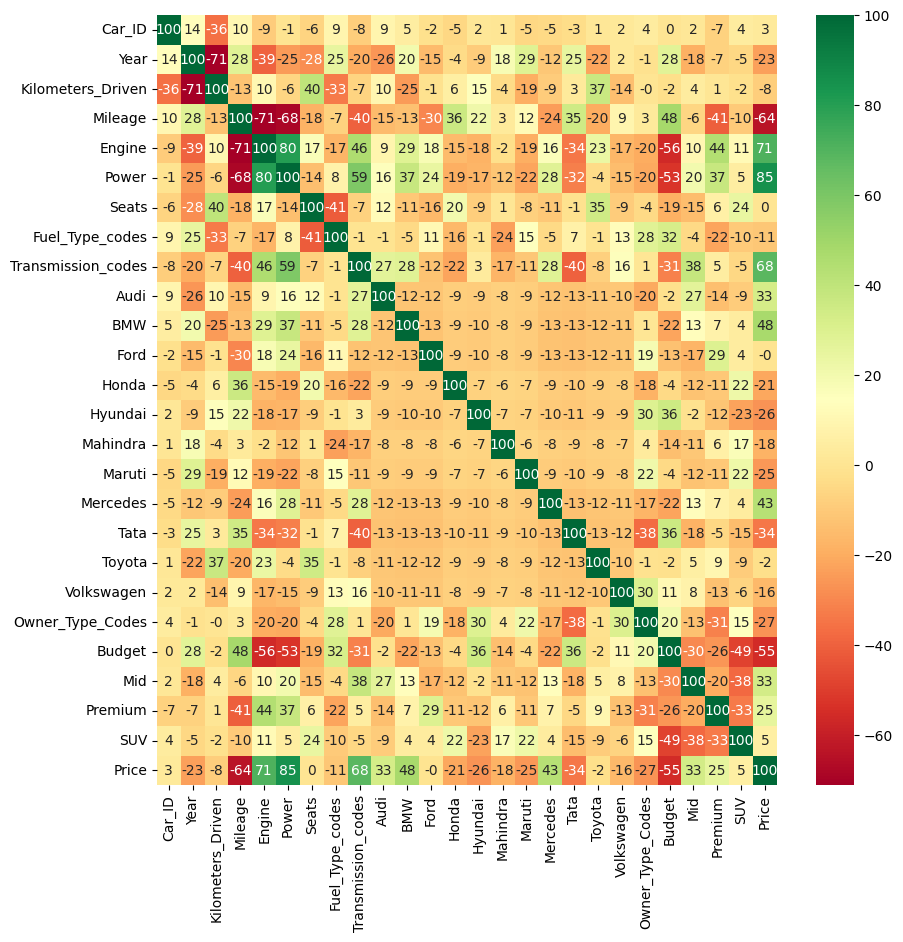

In [28]:
plt.figure(figsize = (10,10))
sns.heatmap(data = Train.corr()*100, annot = True, cmap = "RdYlGn", cbar = True, fmt='.0f')
plt.show()


Для моделі важливі корреляції тільки з `Target`, тому вибираємо найсильніші по полю `Price`

In [29]:
Train.corr()['Price'][(abs(Train.corr()['Price']) >= 0.5) & (abs(Train.corr()['Price']) <= 0.99)]

,Price
Mileage,-0.64
Engine,0.71
Power,0.85
Transmission_codes,0.68
Budget,-0.55


**Висновок**

Найбільші корреляції між `Price` і ознаками:
 - Power - 0,85
 - Engine - 0,71
 - Transmission_codes - 0,68
 - Mileage - 0,64
 - Budget - 0.55 - це моє додане поле з класу машин

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [30]:
X_train = X_train.select_dtypes('number')
X_test = X_test.select_dtypes('number')

In [31]:
model = LinearRegression().fit(X_train, y_train)
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

loss_train = root_mean_squared_error(y_train, predictions_train)
loss_test = root_mean_squared_error(y_test, predictions_test)

r2_train = r2_score(y_train, predictions_train)
r2_test = r2_score(y_test, predictions_test)

print(f'loss_train: {loss_train}\nloss_test: {loss_test}')
print(f'r2_train: {r2_train}\nr2_test: {r2_test}')

loss_train: 203784.17740615617
loss_test: 252819.206445801
r2_train: 0.9611493073931648
r2_test: 0.8586676591533785


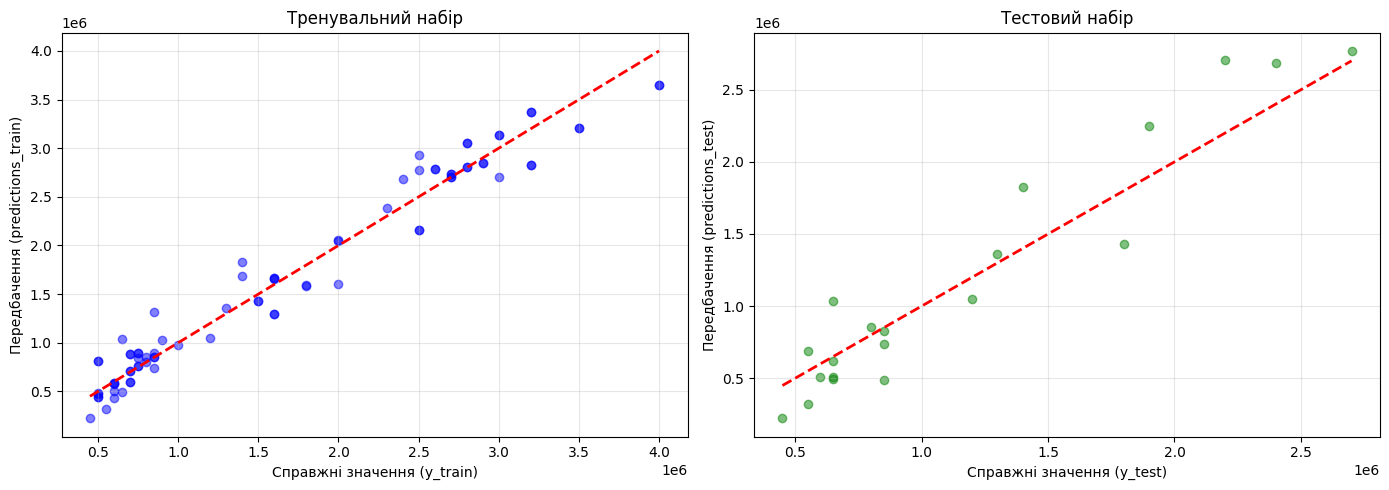

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].scatter(y_train, predictions_train, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2)
axes[0].set_xlabel('Справжні значення (y_train)')
axes[0].set_ylabel('Передбачення (predictions_train)')
axes[0].set_title('Тренувальний набір')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, predictions_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)  # идеальная линия
axes[1].set_xlabel('Справжні значення (y_test)')
axes[1].set_ylabel('Передбачення (predictions_test)')
axes[1].set_title('Тестовий набір')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Висновок**

Модель показує хорошу якість, проте гірше справляєтсья з передбаченням на тестових данних, на що вказують:
1) RMSE - loss train (252 819) > loss test (203 784)  - на 24% вище втрати в тестовому наборі
2) R2 train (0.96) > R2 test (0.85) - тренувальна модель має дуже високий R2, майже ідеальна. Але тестовий набір має нижчий R2 на 11%
3) На графіку видно, що точки на тренувальному наборі лежать близько до лінії, а на тестовому - більше розкидані


**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 83 to 75
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              80 non-null     int64  
 1   Year                80 non-null     int64  
 2   Kilometers_Driven   80 non-null     int64  
 3   Mileage             80 non-null     int64  
 4   Engine              80 non-null     int64  
 5   Power               80 non-null     int64  
 6   Seats               80 non-null     int64  
 7   Fuel_Type_codes     80 non-null     int64  
 8   Transmission_codes  80 non-null     int64  
 9   Audi                80 non-null     float64
 10  BMW                 80 non-null     float64
 11  Ford                80 non-null     float64
 12  Honda               80 non-null     float64
 13  Hyundai             80 non-null     float64
 14  Mahindra            80 non-null     float64
 15  Maruti              80 non-null     float64
 16  Mercedes      

In [34]:
for col in X_train.columns:
    print(f'{col}:')
    value_count = X_train[col].nunique()
    min = X_train[col].min()
    max = X_train[col].max()
    print(f'Кількість значень: {value_count}\nМінімальне значення: {min}\nМаксимальне значення: {max}')
    print()

Car_ID:
Кількість значень: 80
Мінімальне значення: 1
Максимальне значення: 100

Year:
Кількість значень: 6
Мінімальне значення: 2016
Максимальне значення: 2021

Kilometers_Driven:
Кількість значень: 17
Мінімальне значення: 10000
Максимальне значення: 60000

Mileage:
Кількість значень: 15
Мінімальне значення: 10
Максимальне значення: 25

Engine:
Кількість значень: 35
Мінімальне значення: 1047
Максимальне значення: 4951

Power:
Кількість значень: 37
Мінімальне значення: 68
Максимальне значення: 396

Seats:
Кількість значень: 3
Мінімальне значення: 4
Максимальне значення: 7

Fuel_Type_codes:
Кількість значень: 2
Мінімальне значення: 0
Максимальне значення: 1

Transmission_codes:
Кількість значень: 2
Мінімальне значення: 0
Максимальне значення: 1

Audi:
Кількість значень: 2
Мінімальне значення: 0.0
Максимальне значення: 1.0

BMW:
Кількість значень: 2
Мінімальне значення: 0.0
Максимальне значення: 1.0

Ford:
Кількість значень: 2
Мінімальне значення: 0.0
Максимальне значення: 1.0

Honda:
Кіл

Варіант 1 - масштабування всіх колонок

In [35]:
std_scaled_all = StandardScaler()
std_scaled_all.fit(X_train)
X_train_scaled_all = std_scaled_all.transform(X_train)
X_test_scaled_all = std_scaled_all.transform(X_test)

model_scaled_all = LinearRegression().fit(X_train_scaled_all, y_train)
predictions_train_scaled_all = model_scaled_all.predict(X_train_scaled_all)
predictions_test_scaled_all = model_scaled_all.predict(X_test_scaled_all)

loss_train_scaled_all = root_mean_squared_error(y_train, predictions_train_scaled_all)
loss_test_scaled_all = root_mean_squared_error(y_test, predictions_test_scaled_all)

r2_train_scaled_all = r2_score(y_train, predictions_train_scaled_all)
r2_test_scaled_all = r2_score(y_test, predictions_test_scaled_all)

print(f'loss_train_scaled_all: {loss_train_scaled_all}\nloss_test_scaled_all: {loss_test_scaled_all}')
print(f'r2_train_scaled_all: {r2_train_scaled_all}\nr2_test_scaled_all: {r2_test_scaled_all}')

loss_train_scaled_all: 203784.1774061563
loss_test_scaled_all: 252819.20644581263
r2_train_scaled_all: 0.9611493073931647
r2_test_scaled_all: 0.8586676591533655


Результат не змінився

In [36]:
for col in pd.DataFrame(X_train_scaled_all).columns:
    print(f'{col}:')
    value_count = pd.DataFrame(X_train_scaled_all)[col].nunique()
    min = pd.DataFrame(X_train_scaled_all)[col].min()
    max = pd.DataFrame(X_train_scaled_all)[col].max()
    print(f'Кількість значень: {value_count}\nМінімальне значення: {min}\nМаксимальне значення: {max}')
    print()

0:
Кількість значень: 80
Мінімальне значення: -1.8453349149141096
Максимальне значення: 1.6569542118819

1:
Кількість значень: 6
Мінімальне значення: -2.1079523517629557
Максимальне значення: 2.353322466783068

2:
Кількість значень: 17
Мінімальне значення: -2.002546606878364
Максимальне значення: 3.450269204907515

3:
Кількість значень: 15
Мінімальне значення: -2.070625288981135
Максимальне значення: 2.3271629354035768

4:
Кількість значень: 35
Мінімальне значення: -1.315246040648041
Максимальне значення: 4.629523687064316

5:
Кількість значень: 37
Мінімальне значення: -1.2144868775590345
Максимальне значення: 2.8138452760434265

6:
Кількість значень: 3
Мінімальне значення: -1.6527289805194672
Максимальне значення: 2.3947705636098413

7:
Кількість значень: 2
Мінімальне значення: -1.0253204627247283
Максимальне значення: 0.9753048303966929

8:
Кількість значень: 2
Мінімальне значення: -1.2572371141874243
Максимальне значення: 0.7953949089757173

9:
Кількість значень: 2
Мінімальне значен

Варіант 2 - масштабування тільки незакодованих колонок

In [37]:
numeric_cols = ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

std_scaled_num = StandardScaler()
std_scaled_num.fit(X_train[numeric_cols])
X_train_scaled_num = X_train.copy()
X_train_scaled_num[numeric_cols] = std_scaled_num.transform(X_train[numeric_cols])

X_test_scaled_num = X_test.copy()
X_test_scaled_num[numeric_cols] = std_scaled_num.transform(X_test[numeric_cols])

model_scaled_num = LinearRegression().fit(X_train_scaled_num, y_train)
predictions_train_scaled_num = model_scaled_num.predict(X_train_scaled_num)
predictions_test_scaled_num = model_scaled_num.predict(X_test_scaled_num)

loss_train_scaled_num = root_mean_squared_error(y_train, predictions_train_scaled_num)
loss_test_scaled_num = root_mean_squared_error(y_test, predictions_test_scaled_num)

r2_train_scaled_num = r2_score(y_train, predictions_train_scaled_num)
r2_test_scaled_num = r2_score(y_test, predictions_test_scaled_num)

print(f'loss_train_scaled_num: {loss_train_scaled_num}\nloss_test_scaled_num: {loss_test_scaled_num}')
print(f'r2_train_scaled_num: {r2_train_scaled_num}\nr2_test_scaled_num: {r2_test_scaled_num}')

loss_train_scaled_num: 203784.17740615635
loss_test_scaled_num: 252819.20644581167
r2_train_scaled_num: 0.9611493073931647
r2_test_scaled_num: 0.8586676591533666


Результат знову такий самий


Масшибування не змінює саму модель, воно тільки робить коефіцієнти меншими, але і ознаки вже машстабовані

In [38]:
for col in X_train_scaled_num.columns:
    print(f'{col}:')
    value_count = X_train_scaled_num[col].nunique()
    min = X_train_scaled_num[col].min()
    max = X_train_scaled_num[col].max()
    print(f'Кількість значень: {value_count}\nМінімальне значення: {min}\nМаксимальне значення: {max}')
    print()

Car_ID:
Кількість значень: 80
Мінімальне значення: -1.8453349149141096
Максимальне значення: 1.6569542118819

Year:
Кількість значень: 6
Мінімальне значення: -2.1079523517629557
Максимальне значення: 2.353322466783068

Kilometers_Driven:
Кількість значень: 17
Мінімальне значення: -2.002546606878364
Максимальне значення: 3.450269204907515

Mileage:
Кількість значень: 15
Мінімальне значення: -2.070625288981135
Максимальне значення: 2.3271629354035768

Engine:
Кількість значень: 35
Мінімальне значення: -1.315246040648041
Максимальне значення: 4.629523687064316

Power:
Кількість значень: 37
Мінімальне значення: -1.2144868775590345
Максимальне значення: 2.8138452760434265

Seats:
Кількість значень: 3
Мінімальне значення: -1.6527289805194672
Максимальне значення: 2.3947705636098413

Fuel_Type_codes:
Кількість значень: 2
Мінімальне значення: 0
Максимальне значення: 1

Transmission_codes:
Кількість значень: 2
Мінімальне значення: 0
Максимальне значення: 1

Audi:
Кількість значень: 2
Мінімальне

Аналіз самих коефіцієнтів в 3-х моделях:
- model - без масштабування
- model_scaled_all - масштабування всіх колонок
- model_scaled_num - масштабування тільки незакодованих колонок

In [39]:
coefficients = np.append(model.coef_, model.intercept_)
feature_names = list(X_train.columns) + ['Intercept']

# Создай DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df

,Feature,Coefficient
0,Car_ID,33.24
1,Year,27 945.28
2,Kilometers_Driven,-7.81
3,Mileage,-32 872.31
4,Engine,-1.84
5,Power,5 707.11
6,Seats,-17 696.53
7,Fuel_Type_codes,-327 468.30
8,Transmission_codes,222 740.43
9,Audi,817 020.50


In [40]:
coefficients_all = np.append(model_scaled_all.coef_, model_scaled_all.intercept_)
feature_names_all = list(X_train.columns) + ['Intercept']

# Создай DataFrame
coef_df_all = pd.DataFrame({
    'Feature': feature_names_all,
    'Coefficient': coefficients_all
})

coef_df_all

,Feature,Coefficient
0,Car_ID,939.71
1,Year,31 319.84
2,Kilometers_Driven,-71 640.72
3,Mileage,-112 121.05
4,Engine,-1 205.21
5,Power,464 691.43
6,Seats,-13 116.64
7,Fuel_Type_codes,-163 682.98
8,Transmission_codes,108 514.54
9,Audi,221 677.30


In [41]:
coefficients_num = np.append(model_scaled_num.coef_, model_scaled_num.intercept_)
feature_names_num = list(X_train.columns) + ['Intercept']

# Создай DataFrame
coef_df_num = pd.DataFrame({
    'Feature': feature_names_num,
    'Coefficient': coefficients_num,
    'Coefficient_ABS': abs(coefficients_num)
})

coef_df_num.sort_values(by = 'Coefficient_ABS',ascending=False )

,Feature,Coefficient,Coefficient_ABS
25,Intercept,1 577 006.35,1 577 006.35
9,Audi,817 020.50,817 020.50
16,Mercedes,751 112.66,751 112.66
10,BMW,712 253.74,712 253.74
14,Mahindra,-649 682.02,649 682.02
15,Maruti,-481 099.62,481 099.62
5,Power,464 691.43,464 691.43
13,Hyundai,-428 877.62,428 877.62
7,Fuel_Type_codes,-327 468.30,327 468.30
11,Ford,-292 686.57,292 686.57


 **Висновок**

 Аналізувати буду на моделі `model_scaled_num`, де масштабовані тільки незакодовані колонки

 Найвпливовіші колонки:
 - Brand (Audi, Mercedes, BMW - дорогі авто) +700-800k / (Mahindra, Maruti, Hyundai - дешеві авто) -600-400k
 - Power +465k
 - Fuel_Type_codes -327K. За нашим мапінгом {'Diesel': 0, 'Petrol': 1} виходить, що машини на Petrol знижують ціну машини
 - Transmission_codes +222k. За нашим мапінгом {'Manual': 0, 'Automatic': 1}виходить, що машини на Automatic збільшують ціну машини
 - Car_class (Budget, SUV, Mid, Premium) — SUV, Mid та Premium збільшують ціну, а Budgetт - зменшує
- Mileage та Kilometers_Driven - мінус за каждый км - зменшують ціну
- Year — новее = дороже
- Seats -чим більше, тим нижче ціна

Виглядає логічно

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [42]:
X_train_sm = sm.add_constant(X_train_scaled_num)
X_test_sm = sm.add_constant(X_test_scaled_num)

model_stat = sm.OLS(y_train, X_train_sm).fit()

predictions_train = model_stat.predict(X_train_sm)
predictions_test = model_stat.predict(X_test_sm)

model_stat.params

#print(model_stat.summary())


,0
const,1 176 072.53
Car_ID,939.71
Year,31 319.84
Kilometers_Driven,-71 640.72
Mileage,-112 121.05
Engine,-1 205.21
Power,464 691.43
Seats,-13 116.64
Fuel_Type_codes,-327 468.30
Transmission_codes,222 740.43


In [43]:
coef_sklearn = model_scaled_num.coef_
coef_sm = model_stat.params[1:]

print("Sklearn:", coef_sklearn)
print("Statsmodels:", coef_sm.values)

Sklearn: [    939.70761199   31319.83544016  -71640.71898605 -112121.04728241
   -1205.20610689  464691.43153624  -13116.6400853  -327468.3028056
  222740.42656608  817020.50340696  712253.74129128 -292686.56985272
 -219580.24872169 -428877.61662484 -649682.01847938 -481099.62482429
  751112.65765989 -100694.93321198  135479.2543832  -243245.14502643
   78564.72900735 -135083.65020988   52187.48646494   25566.59771864
   57329.5660263 ]
Statsmodels: [    939.70761199   31319.83544016  -71640.71898605 -112121.04728242
   -1205.20610689  464691.43153624  -13116.6400853  -327468.3028056
  222740.42656609  923936.18803205  819169.42591637 -185770.88522763
 -112664.5640966  -321961.93199974 -542766.33385429 -374183.9401992
  858028.34228498    6220.75141311  242394.9390083  -136329.46040134
   78564.72900735  158934.48250912  346205.61918394  319584.73043764
  351347.6987453 ]


Коефіцієнти трохи відрізняються в stat через мультиколленіарність категоріальних змінних

In [44]:
print(model_stat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     60.24
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.91e-31
Time:                        14:37:43   Log-Likelihood:                -1091.5
No. Observations:                  80   AIC:                             2231.
Df Residuals:                      56   BIC:                             2288.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.176e+06   6.29

Стат значущими на рівні значущості < 0.05 є такі ознаки:
- const
- Power
- Fuel_Type_codes
- Transmission_codes
- Brand (Audi, BMW, Hyundai, Mahindra, Maruti, Mercedes, Toyota)
- Car_class (Mid, Premium, SUV)



**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [45]:
X_train_sm_pv = X_train_scaled_num[['Power', 'Fuel_Type_codes', 'Transmission_codes', 'Audi', 'BMW', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Toyota', 'Mid', 'Premium', 'SUV']]
X_train_sm_pv = sm.add_constant(X_train_sm_pv)

model_stat_pv = sm.OLS(y_train, X_train_sm_pv).fit()

predictions_train = model_stat_pv.predict(X_train_sm_pv)

print(model_stat_pv.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     103.7
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.23e-38
Time:                        14:37:43   Log-Likelihood:                -1098.9
No. Observations:                  80   AIC:                             2226.
Df Residuals:                      66   BIC:                             2259.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.151e+06   1.15

**Висновок**

Моделі мають дуже схожі показники R2 і Adj. R-squared

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [46]:
X_train_sm_pv025 = X_train_scaled_num[['Power', 'Fuel_Type_codes', 'Transmission_codes', 'Audi', 'BMW', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Toyota', 'Mid', 'Premium', 'SUV', 'Mileage', 'Ford', 'Volkswagen', 'Budget']]
X_train_sm_pv025 = sm.add_constant(X_train_sm_pv025)

model_stat_pv025 = sm.OLS(y_train, X_train_sm_pv025).fit()

predictions_train = model_stat_pv025.predict(X_train_sm_pv025)

print(model_stat_pv025.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     85.95
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.66e-36
Time:                        14:37:44   Log-Likelihood:                -1096.3
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      63   BIC:                             2267.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.071e+06   7.63

**Висновок**

Модель на всіх ознаках
- R-squared:                       0.961
- Adj. R-squared:                  0.945

Модель на значущих ознаках (p-value < 0.05)
- R-squared:                       0.953
- Adj. R-squared:                  0.944

Модель на значущих ознаках (p-value < 0.25)
- R-squared:                       0.956
- Adj. R-squared:                  0.0.945


Я би залишала 2-гий варіант з ознаками зі стат значущостю 0,05:
- її точність майже не впала (R2 трошечки менший)
- вона використовує менше ознак, а значить швидше вчиться